In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# /content/drive/MyDrive/aptos2019-blindness-detection.zip

In [3]:
import zipfile
# Dataset: https://www.kaggle.com/datasets/tamimresearch/weather-image-dataset
zip_path = "/content/drive/MyDrive/aptos2019-blindness-detection.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [4]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

# Define paths
DATA_DIR = "/content/data"
TRAIN_CSV_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_CSV_PATH = os.path.join(DATA_DIR, "test.csv")
TRAIN_IMAGE_DIR = os.path.join(DATA_DIR, "train_images")
TEST_IMAGE_DIR = os.path.join(DATA_DIR, "test_images")

# Load dataframes
try:
    train_df_full = pd.read_csv(TRAIN_CSV_PATH)
    test_df = pd.read_csv(TEST_CSV_PATH)
except FileNotFoundError:
    print(f"Error: Ensure '{TRAIN_CSV_PATH}' and '{TEST_CSV_PATH}' exist. They should be extracted from the zip file.")
    raise

# Split train_df into train and validation sets
train_df, val_df = train_test_split(train_df_full, test_size=0.2, random_state=42, stratify=train_df_full['diagnosis'])

print(f"Full training data size: {len(train_df_full)}")
print(f"Training data size: {len(train_df)}")
print(f"Validation data size: {len(val_df)}")
print(f"Test data size: {len(test_df)}")

# Define transformations
image_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
}

# Load all images into memory and create lists of (tensor, label/id) tuples

print("\nLoading and transforming images for training dataset...")
train_data_list = []
for idx, row in train_df.iterrows():
    img_id = row['id_code']
    img_name = os.path.join(TRAIN_IMAGE_DIR, img_id + '.png')
    image = Image.open(img_name).convert("RGB")
    image_tensor = image_transforms['train'](image)
    label = row['diagnosis']
    train_data_list.append((image_tensor, torch.tensor(label, dtype=torch.long)))

print("Loading and transforming images for validation dataset...")
val_data_list = []
for idx, row in val_df.iterrows():
    img_id = row['id_code']
    img_name = os.path.join(TRAIN_IMAGE_DIR, img_id + '.png') # Val images are also from TRAIN_IMAGE_DIR
    image = Image.open(img_name).convert("RGB")
    image_tensor = image_transforms['val_test'](image)
    label = row['diagnosis']
    val_data_list.append((image_tensor, torch.tensor(label, dtype=torch.long)))

print("Loading and transforming images for test dataset...")
test_data_list = []
for idx, row in test_df.iterrows():
    img_id = row['id_code']
    img_name = os.path.join(TEST_IMAGE_DIR, img_id + '.png')
    image = Image.open(img_name).convert("RGB")
    image_tensor = image_transforms['val_test'](image)
    # For test set, we return image and its ID, not a label
    test_data_list.append((image_tensor, img_id))

# Now these lists serve as our "datasets"
train_dataset = train_data_list
val_dataset = val_data_list
test_dataset = test_data_list

# Create DataLoader instances
BATCH_SIZE = 32
NUM_WORKERS = 0 # Set to 0 because all images are pre-loaded into memory, no need for multiprocessing to load from disk.

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("\nDataLoaders created successfully:")
print(f"Train DataLoader batches: {len(train_dataloader)}")
print(f"Validation DataLoader batches: {len(val_dataloader)}")
print(f"Test DataLoader batches: {len(test_dataloader)}")




Full training data size: 3662
Training data size: 2929
Validation data size: 733
Test data size: 1928

Loading and transforming images for training dataset...
Loading and transforming images for validation dataset...
Loading and transforming images for test dataset...

DataLoaders created successfully:
Train DataLoader batches: 92
Validation DataLoader batches: 23
Test DataLoader batches: 61


In [5]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models


num_classes = 5 # APTOS 2019 dataset has 5 diagnosis classes (0-4)

# Load a pre-trained ResNet50 model
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

print("Model architecture defined:")
print(model)


Model architecture defined:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, ker

In [6]:
# 2. Move Model to Device (GPU if available)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model moved to: {device}")


Model moved to: cuda:0


In [7]:
# 3. Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Learning rate can be tuned

print("Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.")


Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.


Now that the model, loss function, and optimizer are defined, we can set up the training loop. The following cell provides a basic structure for training and validation. You'll need to fill in the specific logic for metrics calculation, early stopping, and saving the best model.

In [8]:
num_epochs = 10 # Example number of epochs

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    # Training phase
    model.train() # Set model to training mode
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward + optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    # Validation phase
    model.eval() # Set model to evaluate mode
    val_running_loss = 0.0
    val_running_corrects = 0

    # Disable gradient calculation for validation
    with torch.no_grad():
        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_running_loss / len(val_dataset)
    val_epoch_acc = val_running_corrects.double() / len(val_dataset)

    print(f'Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}')
    print()

print('Training complete')



Epoch 1/10
----------
Train Loss: 0.7747 Acc: 0.7115
Val Loss: 1.1071 Acc: 0.5102

Epoch 2/10
----------
Train Loss: 0.6215 Acc: 0.7689
Val Loss: 0.7862 Acc: 0.6412

Epoch 3/10
----------
Train Loss: 0.5532 Acc: 0.7965
Val Loss: 1.0952 Acc: 0.5375

Epoch 4/10
----------
Train Loss: 0.5275 Acc: 0.8023
Val Loss: 0.7316 Acc: 0.7735

Epoch 5/10
----------
Train Loss: 0.4904 Acc: 0.8088
Val Loss: 0.6339 Acc: 0.7831

Epoch 6/10
----------
Train Loss: 0.4461 Acc: 0.8286
Val Loss: 0.6068 Acc: 0.7804

Epoch 7/10
----------
Train Loss: 0.4210 Acc: 0.8348
Val Loss: 0.6215 Acc: 0.7817

Epoch 8/10
----------
Train Loss: 0.3749 Acc: 0.8511
Val Loss: 0.7862 Acc: 0.7790

Epoch 9/10
----------
Train Loss: 0.3414 Acc: 0.8665
Val Loss: 1.2104 Acc: 0.6467

Epoch 10/10
----------
Train Loss: 0.3227 Acc: 0.8798
Val Loss: 0.7440 Acc: 0.7776

Training complete


In [9]:
# Use EfficientNet or Vision Transformer for better performance
from torchvision import models
import timm

# Option 1: EfficientNet (state-of-the-art for medical imaging)
# model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=5)

# Option 2: Vision Transformer
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=5)

# Move the new model to the device (GPU if available)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [10]:
from torch.utils.data import WeightedRandomSampler

# Calculate class weights
class_counts = train_df['diagnosis'].value_counts().sort_index()
class_weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float)
sample_weights = class_weights[train_df['diagnosis'].values]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                             sampler=sampler, num_workers=NUM_WORKERS)

In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(224, 224),
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5), # Changed from A.Flip to A.HorizontalFlip
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0)),
        A.GaussianBlur(),
        A.MotionBlur(),
    ], p=0.3),
    A.OneOf([
        A.OpticalDistortion(distort_limit=0.11),
        A.GridDistortion(num_steps=5, distort_limit=0.3),
    ], p=0.3),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

/tmp/ipykernel_37030/1951159239.py:9: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Quadratic Weighted Kappa (important for this competition!)
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    # Classification report
    print(classification_report(all_labels, all_preds,
                               target_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'],
                yticklabels=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'])
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title(f'Confusion Matrix (Kappa: {kappa:.4f})')
    plt.show()

    return kappa

               precision    recall  f1-score   support

        No DR       0.18      0.02      0.03       361
         Mild       0.12      0.49      0.20        74
     Moderate       0.24      0.12      0.16       200
       Severe       0.06      0.44      0.10        39
Proliferative       0.25      0.02      0.03        59

     accuracy                           0.11       733
    macro avg       0.17      0.22      0.10       733
 weighted avg       0.19      0.11      0.09       733



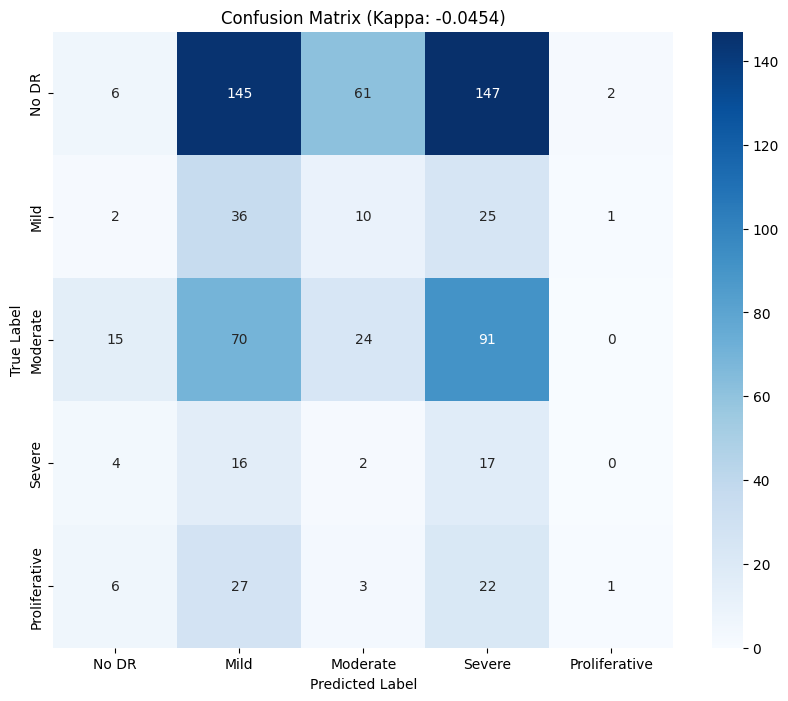

               precision    recall  f1-score   support

        No DR       0.18      0.02      0.03       361
         Mild       0.12      0.49      0.20        74
     Moderate       0.24      0.12      0.16       200
       Severe       0.06      0.44      0.10        39
Proliferative       0.25      0.02      0.03        59

     accuracy                           0.11       733
    macro avg       0.17      0.22      0.10       733
 weighted avg       0.19      0.11      0.09       733



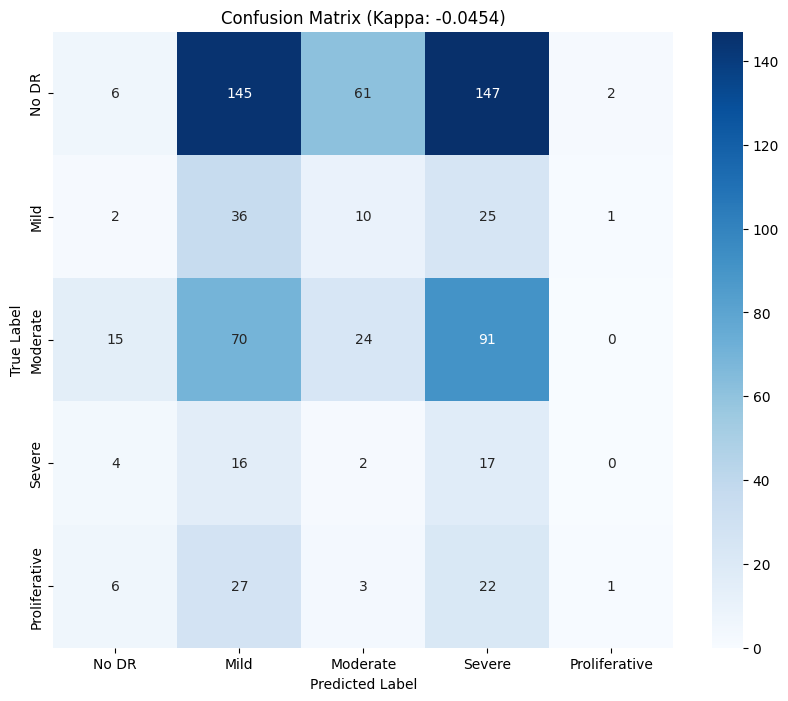

               precision    recall  f1-score   support

        No DR       0.18      0.02      0.03       361
         Mild       0.12      0.49      0.20        74
     Moderate       0.24      0.12      0.16       200
       Severe       0.06      0.44      0.10        39
Proliferative       0.25      0.02      0.03        59

     accuracy                           0.11       733
    macro avg       0.17      0.22      0.10       733
 weighted avg       0.19      0.11      0.09       733



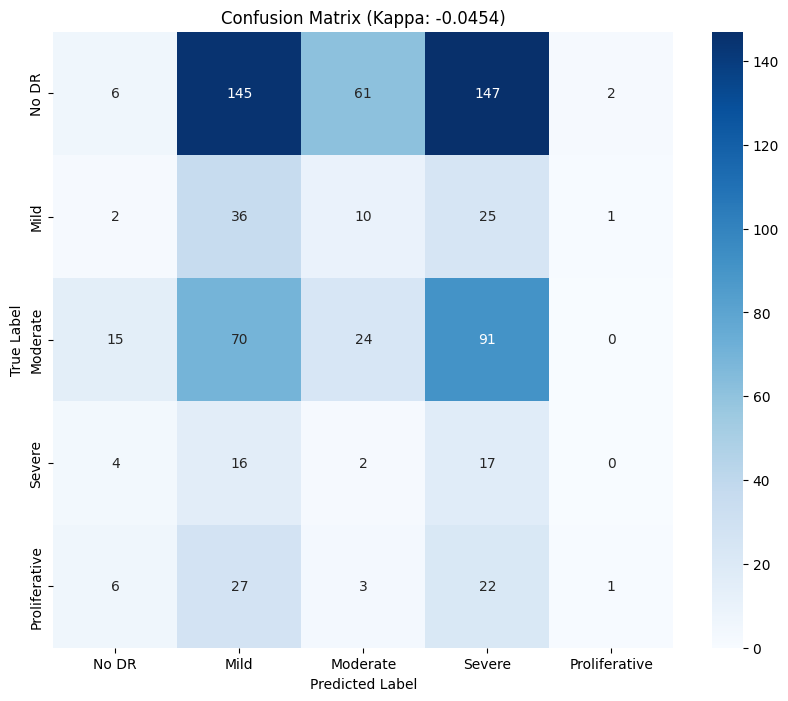

               precision    recall  f1-score   support

        No DR       0.18      0.02      0.03       361
         Mild       0.12      0.49      0.20        74
     Moderate       0.24      0.12      0.16       200
       Severe       0.06      0.44      0.10        39
Proliferative       0.25      0.02      0.03        59

     accuracy                           0.11       733
    macro avg       0.17      0.22      0.10       733
 weighted avg       0.19      0.11      0.09       733



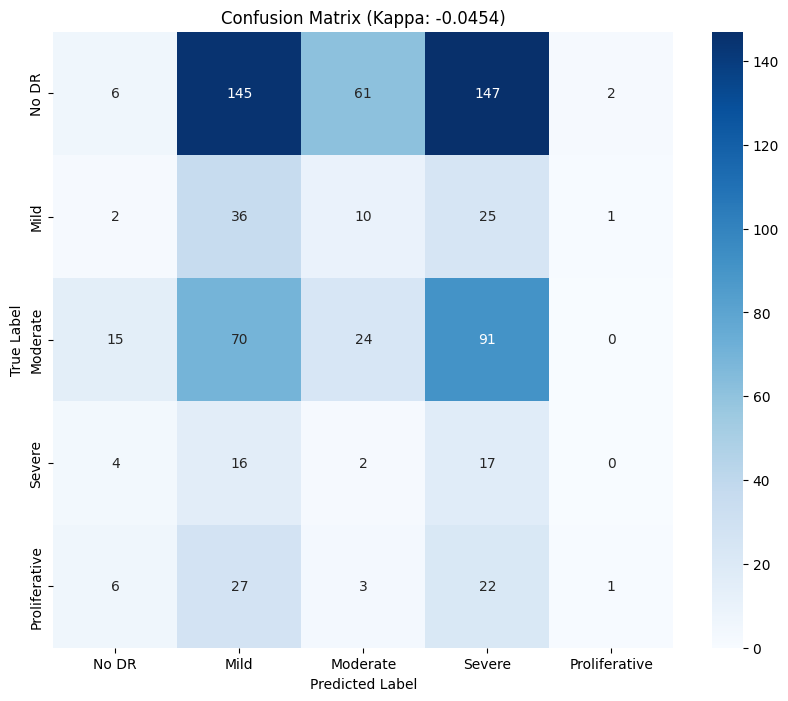

               precision    recall  f1-score   support

        No DR       0.18      0.02      0.03       361
         Mild       0.12      0.49      0.20        74
     Moderate       0.24      0.12      0.16       200
       Severe       0.06      0.44      0.10        39
Proliferative       0.25      0.02      0.03        59

     accuracy                           0.11       733
    macro avg       0.17      0.22      0.10       733
 weighted avg       0.19      0.11      0.09       733



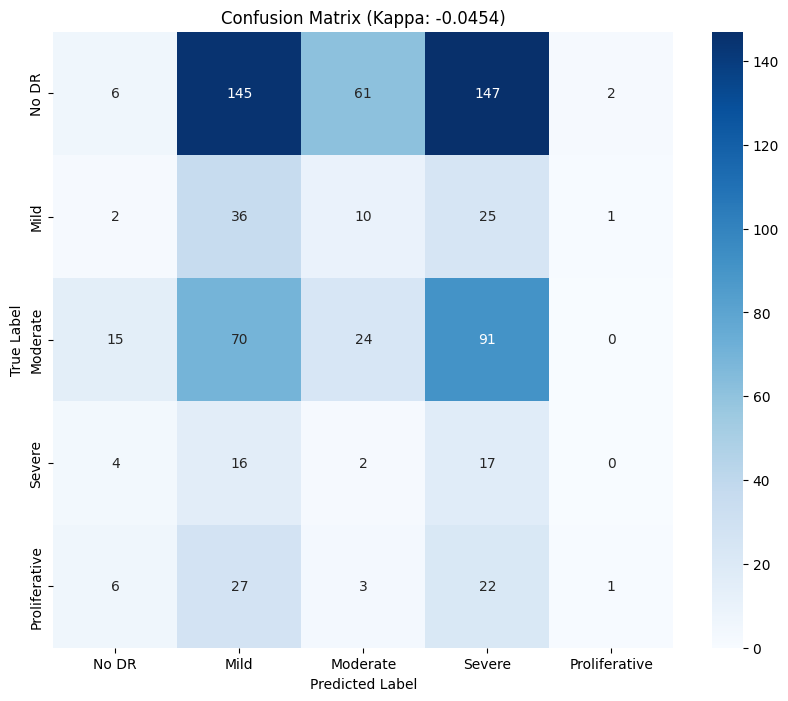

Early stopping triggered!


In [20]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn
import torch.optim as optim

# Ensure the model is on the correct device
model = model.to(device)

# Re-initialize criterion and optimizer to ensure they are on the correct device
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Early stopping
best_kappa = 0.0
patience_counter = 0
patience = 5

for epoch in range(num_epochs):
    # ... training code ...

    val_kappa = evaluate_model(model, val_dataloader, device)
    scheduler.step(val_epoch_loss)

    # Save best model
    if val_kappa > best_kappa:
        best_kappa = val_kappa
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered!")
        break

In [22]:
accumulation_steps = 4  # Effective batch size = 32 * 4 = 128

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    for i, (inputs, labels) in enumerate(train_dataloader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss = loss / accumulation_steps
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

In [23]:
from tqdm import tqdm

# Replace print statements with progress bars
train_pbar = tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
for inputs, labels in train_pbar:
    # ... training code ...
    train_pbar.set_postfix({'loss': loss.item(), 'acc': epoch_acc.item()})

Epoch 10/10 [Train]: 100%|██████████| 92/92 [00:00<00:00, 164.10it/s, loss=0.281, acc=0.88]


In [26]:
!pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def visualize_gradcam(model, image, target_layer):
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image.unsqueeze(0))
    # Visualize the attention map on the original image

ERROR: Could not find a version that satisfies the requirement pytorch_grad_cam (from versions: none)
ERROR: No matching distribution found for pytorch_grad_cam


ModuleNotFoundError: No module named 'pytorch_grad_cam'